
# PowerCo Customer Churn Analysis & Retention Strategy

### Investigating Price Sensitivity & Key Churn Drivers


**Business Problem:** PowerCo, a major gas and electricity utility supplying SMEs, is experiencing customer churn.
This analysis investigates whether price sensitivity is the primary driver of churn.

**Datasets:**
- `client_data.csv` — Customer attributes, usage, financials, and churn label (14,606 records)
- `price_data.csv` — Monthly variable/fixed prices per customer across tariff periods (193,002 records)

**Notebook Structure:**
1. Load & Inspect Data
2. Feature Engineering & Segment Churn Analysis
3. Statistical Analysis, Price Sensitivity & Predictive Modelling
4. Customer Value Analytics: CLV Estimation, Revenue at Risk, and Retention Roadmap


---
<a id='section-1'></a>
### Load & Inspect Both CSV Files
Initial data profiling: shape, dtypes, missing values, and class balance.

In [20]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# Load client data
client = pd.read_csv("D:\Data Analysis\customer_churn_analysis\client_data.csv")

# Load price data
price = pd.read_csv("D:\Data Analysis\customer_churn_analysis\price_data.csv")


In [3]:

print("CLIENT DATA")
print("-" * 55)

print(f"Shape            : {client.shape[0]:,} rows × {client.shape[1]} columns")
print(f"Unique customers : {client['id'].nunique():,}")

print("\nColumns & Data Types:")
print(client.dtypes)


CLIENT DATA
-------------------------------------------------------
Shape            : 14,606 rows × 26 columns
Unique customers : 14,606

Columns & Data Types:
id                                 object
channel_sales                      object
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
date_activ                         object
date_end                           object
date_modif_prod                    object
date_renewal                       object
forecast_cons_12m                 float64
forecast_cons_year                  int64
forecast_discount_energy          float64
forecast_meter_rent_12m           float64
forecast_price_energy_off_peak    float64
forecast_price_energy_peak        float64
forecast_price_pow_off_peak       float64
has_gas                            object
imp_cons                          float64
margin_gross_pow_ele              float64
margin_net_pow_ele                float64

In [7]:

client.head(3)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


### Client data - missing values

In [4]:

print("Missing values per column:")

missing = client.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    print(missing)
else:
    print("No missing values detected ✓")


Missing values per column:
No missing values detected ✓


### Churn class balance

In [8]:

churn_counts = client["churn"].value_counts()
churn_rate = client["churn"].mean()

print("Churn Distribution")
print("-" * 30)

print(
    f"Retained (0) : {churn_counts[0]:>6,} "
    f"({(1 - churn_rate) * 100:.1f}%)"
)

print(
    f"Churned  (1) : {churn_counts[1]:>6,} "
    f"({churn_rate * 100:.1f}%)"
)

print(
    f"Imbalance Ratio : 1 : {churn_counts[0] / churn_counts[1]:.1f}"
)


Churn Distribution
------------------------------
Retained (0) : 13,187 (90.3%)
Churned  (1) :  1,419 (9.7%)
Imbalance Ratio : 1 : 9.3


### Summary statistics — client numeric features

In [9]:

num_cols = client.select_dtypes(include="number").columns

client[num_cols].describe().round(2)


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.0
mean,159220.29,28092.38,16090.27,1868.61,1399.76,0.97,63.09,0.14,0.05,43.13,152.79,24.57,24.56,1.29,189.26,5.00,18.14,0.1
std,573465.26,162973.06,64364.20,2387.57,3247.79,5.11,66.17,0.02,0.05,4.49,341.37,20.23,20.23,0.71,311.80,1.61,13.53,0.3
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,3.30,0.0
25%,5674.75,0.00,0.00,495.00,0.00,0.00,16.18,0.12,0.00,40.61,0.00,14.28,14.28,1.00,50.71,4.00,12.50,0.0
50%,14115.50,0.00,792.50,1112.88,314.00,0.00,18.80,0.14,0.08,44.31,37.39,21.64,21.64,1.00,112.53,5.00,13.86,0.0
75%,40763.75,0.00,3383.00,2401.79,1745.75,0.00,131.03,0.15,0.10,44.31,193.98,29.88,29.88,1.00,243.10,6.00,19.17,0.0
max,6207104.00,4154590.00,771203.00,82902.83,175375.00,30.00,599.31,0.27,0.20,59.27,15042.79,374.64,374.64,32.00,24570.65,13.00,320.00,1.0


In [11]:

print("PRICE DATA")
print("-" * 55)

print(f"Shape            : {price.shape[0]:,} rows × {price.shape[1]} columns")
print(f"Unique customers : {price['id'].nunique():,}")

print("\nColumns & Data Types:")
print(price.dtypes)


PRICE DATA
-------------------------------------------------------
Shape            : 193,002 rows × 8 columns
Unique customers : 16,096

Columns & Data Types:
id                     object
price_date             object
price_off_peak_var    float64
price_peak_var        float64
price_mid_peak_var    float64
price_off_peak_fix    float64
price_peak_fix        float64
price_mid_peak_fix    float64
dtype: object


In [12]:

price.head(3)


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


### Price data — missing values & date range

In [13]:

print("Missing values in price data:")

missing_price = price.isnull().sum()
missing_price = missing_price[missing_price > 0]

if len(missing_price) > 0:
    print(missing_price)
else:
    print("No missing values detected ✓")

price["price_date"] = pd.to_datetime(price["price_date"])

print(
    f"\nDate Range : "
    f"{price['price_date'].min().date()} → "
    f"{price['price_date'].max().date()}"
)

print(f"Months Covered          : {price['price_date'].nunique()}")
print(
    f"Average Records/Customer: "
    f"{price.shape[0] / price['id'].nunique():.1f}"
)


Missing values in price data:
No missing values detected ✓

Date Range : 2015-01-01 → 2015-12-01
Months Covered          : 12
Average Records/Customer: 12.0


### Price data — summary statistics

In [16]:

price.describe().round(5)


,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002,193002.00000,193002.00000,193002.00000,193002.00000,193002.00000,193002.00000
mean,2015-06-16 12:50:49.933161216,0.14103,0.05463,0.03050,43.33448,10.62288,6.40998
min,2015-01-01 00:00:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,2015-04-01 00:00:00,0.12598,0.00000,0.00000,40.72888,0.00000,0.00000
50%,2015-07-01 00:00:00,0.14603,0.08548,0.00000,44.26693,0.00000,0.00000
75%,2015-10-01 00:00:00,0.15164,0.10167,0.07256,44.44471,24.33958,16.22639
max,2015-12-01 00:00:00,0.28070,0.22979,0.11410,59.44471,36.49069,17.45822
std,NaN,0.02503,0.04992,0.03630,5.41030,12.84189,7.77359


### Data Visualsation

In [31]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    
    ax = dataframe.plot(kind="bar", stacked=True, figsize=size_, rot=rot_, title=title_)

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):

    """Add value annotations to the bars"""
    
    # Iterate over the plotted rectanges/bars
    for p in ax.patches:
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            f"{p.get_height():.1f}",
            (
                p.get_x() + p.get_width() / 2,
                p.get_y() + p.get_height() / 2
            ),
            ha="center",
            va="center",
            color="white",
            fontsize=textsize
        )


### Churn

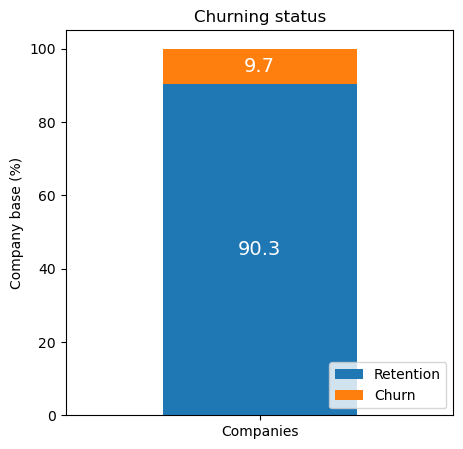

In [30]:
churn = client[['id', 'churn']]

churn_percentage = (churn.groupby('churn').count().rename(columns={'id': 'Companies'}).div(len(churn)).mul(100))

plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")


About 10% of the total customers have churned. 